In [ ]:
!pip install tensorflow



In [2]:
pip install keras


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

#import keras
from keras.models import Sequential
from keras.layers import Conv2D, Lambda, MaxPooling2D # convolution layers
from keras.layers import Dense, Dropout, Flatten # core layers
#from keras.layers.normalization import BatchNormalization

from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

#from keras.datasets import mnist

ImportError: Traceback (most recent call last):
  File "C:\Users\Kered\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Une routine d’initialisation d’une bibliothèque de liens dynamiques (DLL) a échoué.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [2]:
import os
print(os.listdir(r'C:\Users\Kered\ML_DVRC_2025\Lecture8\CNN\Labs'))

['.ipynb_checkpoints', '01-DNN-MNIST.ipynb', 'MNIST_CNN.ipynb', 'output.png', 'sample_submission.csv', 'test.csv', 'train.csv']


In [3]:
train = pd.read_csv(r'C:\Users\Kered\ML_DVRC_2025\Lecture8\CNN\Labs\train.csv')
test = pd.read_csv(r'C:\Users\Kered\ML_DVRC_2025\Lecture8\CNN\Labs\test.csv')
sub = pd.read_csv(r'C:\Users\Kered\ML_DVRC_2025\Lecture8\CNN\Labs\sample_submission.csv')
print("Data are Ready!!")

Data are Ready!!


In [5]:
X = train.drop(['label'], axis=1).values
y = train['label'].values

# Normalization & Reshape

In [10]:
# X = X / 255.0
# # Reshape image in 3 dimensions (height = 28px, width = 28px , canal = 1)
# # canal = 1 => For gray scale
# X = X.reshape(-1,28,28,1)
# # Encode labels to one hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])
# y = to_categorical(y)

# print(f"Label size {y.shape}")

# Normalisation
X = X.astype("float32") / 255.0

# Reshape images : (N, 28, 28, 1)
X = X.reshape(-1, 28, 28, 1)

# Labels : entiers (PAS de one-hot)
y = y.astype("int64")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y unique labels: {set(y)}")


X shape: (2937, 28, 28, 1)
y shape: (2937,)
y unique labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


# Train test split validation

In [11]:
 #Split the train and the validation set for the fitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2643, 28, 28, 1), (294, 28, 28, 1), (2643,), (294,))

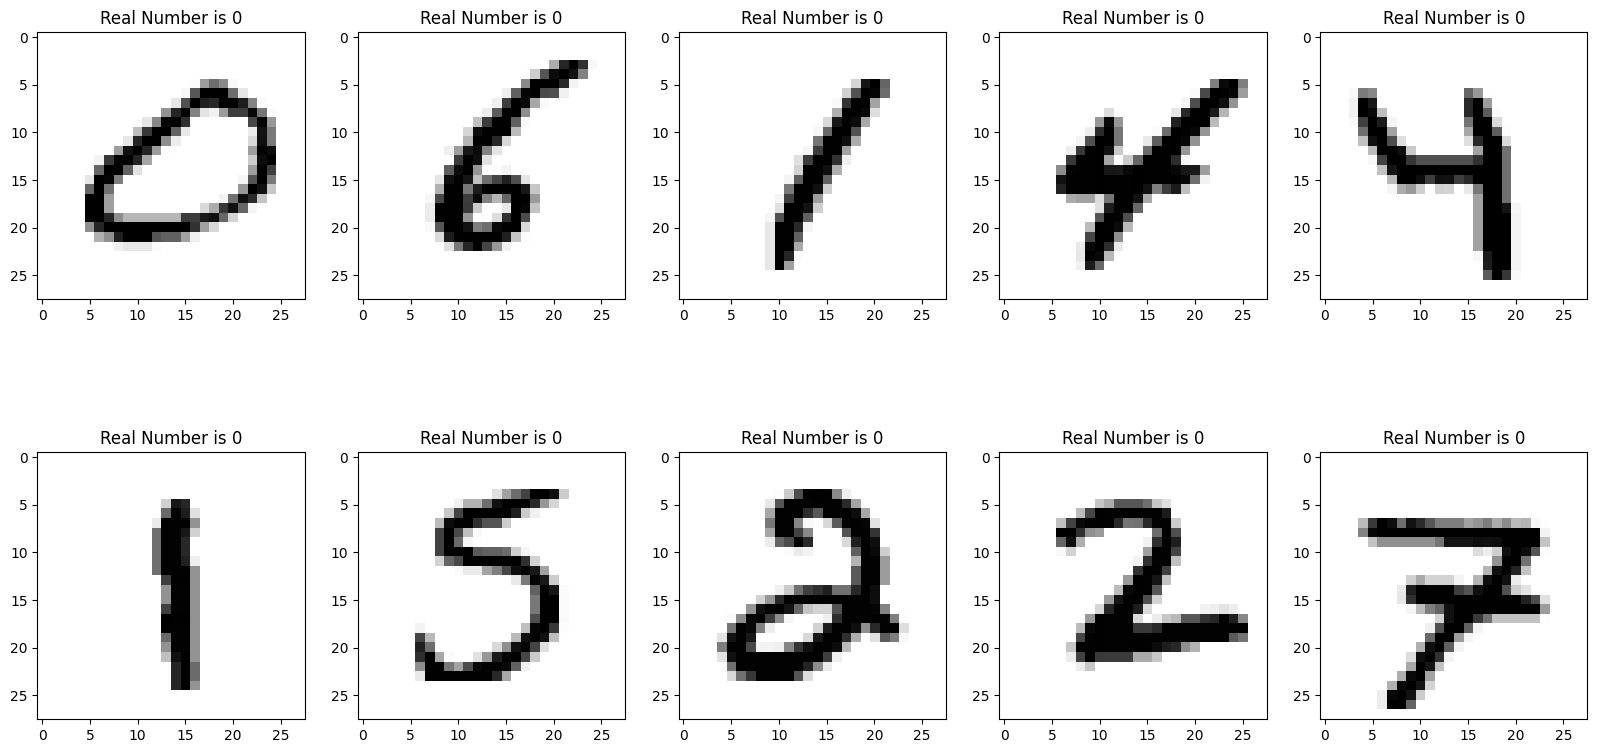

In [13]:
X_train__ = X_train.reshape(X_train.shape[0], 28, 28)

fig, axis = plt.subplots(2, 5, figsize=(20, 10))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_train__[i], cmap='binary')
    digit = y_train[i].argmax()
    ax.set(title = f"Real Number is {digit}");

In [14]:
mean = np.mean(X_train)
std = np.std(X_train)

def standardize(x):
    return (x-mean)/std

In [ ]:
pip install tensorflow==2.10.1


In [ ]:
!pip uninstall tensorflow -y
!pip install tensorflow==2.10.1


In [4]:
import tensorflow as tf
print(tf.__version__)


ImportError: cannot import name 'pywrap_tensorflow' from partially initialized module 'tensorflow.python' (most likely due to a circular import) (c:\fidle-tp\fidle-env\lib\site-packages\tensorflow\python\__init__.py)

In [2]:
#from keras.layers.normalization import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense
)

from tensorflow.keras.layers import BatchNormalization

ImportError: cannot import name 'pywrap_tensorflow' from partially initialized module 'tensorflow.python' (most likely due to a circular import) (C:\Users\Kered\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tensorflow\python\__init__.py)

# Build the model

In [5]:
model=Sequential()

#model.add(Lambda(standardize,input_shape=(28,28,1)))    
model.add(Conv2D(filters=64, kernel_size = (3,3), activation="relu", input_shape=(28,28,1)))
model.add(Conv2D(filters=64, kernel_size = (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size = (3,3), activation="relu"))
model.add(Conv2D(filters=128, kernel_size = (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())    

model.add(Conv2D(filters=256, kernel_size = (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
    
model.add(Flatten())
model.add(Dense(512,activation="relu"))
    
model.add(Dense(10,activation="softmax"))
 
#Compile the model    
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

NameError: name 'Sequential' is not defined

In [36]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 26, 26, 64)        640       
                                                                 
 conv2d_10 (Conv2D)          (None, 24, 24, 64)        36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 12, 12, 64)       0         
 2D)                                                             
                                                                 
 batch_normalization (BatchN  (None, 12, 12, 64)       256       
 ormalization)                                                   
                                                                 
 conv2d_11 (Conv2D)          (None, 10, 10, 128)       73856     
                                                                 
 conv2d_12 (Conv2D)          (None, 8, 8, 128)        

In [24]:
pip install visualkeras

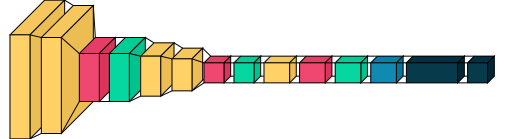

In [37]:
import visualkeras

visualkeras.layered_view(model).show() # display using your system viewer
visualkeras.layered_view(model, to_file='output.png') # write to disk
visualkeras.layered_view(model, to_file='output.png').show() # write and show

visualkeras.layered_view(model)

In [ ]:
# With data augmentation to prevent overfitting

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=15,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.01, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images


#datagen.fit(X_train)
train_gen = datagen.flow(X_train, y_train, batch_size=128)
test_gen = datagen.flow(X_test, y_test, batch_size=128)

In [47]:
epochs = 50
batch_size = 128
train_steps = X_train.shape[0] // batch_size
valid_steps = X_test.shape[0] // batch_size

es = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", # metrics to monitor
        patience=10, # how many epochs before stop
        verbose=2,
        mode="max", # we need the maximum accuracy.
        restore_best_weights=True, # 
     )

rp = keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.2,
        patience=3,
        verbose=1,
        mode="max",
        min_lr=0.00001,
     )

In [50]:
# Fit the model
history = model.fit(train_gen, 
                              epochs = epochs, 
                              steps_per_epoch = train_steps,
                              validation_data = test_gen,
                              validation_steps = valid_steps, 
                              callbacks=[es, rp])

Epoch 1/50
20/20 [==============================] - 10s 507ms/step - loss: nan - accuracy: 0.0994 - val_loss: nan - val_accuracy: 0.1172 - lr: 1.0000e-05
Epoch 2/50
20/20 [==============================] - 10s 489ms/step - loss: nan - accuracy: 0.0974 - val_loss: nan - val_accuracy: 0.1250 - lr: 1.0000e-05
Epoch 3/50
20/20 [==============================] - 11s 530ms/step - loss: nan - accuracy: 0.0990 - val_loss: nan - val_accuracy: 0.1211 - lr: 1.0000e-05
Epoch 4/50
20/20 [==============================] - 10s 515ms/step - loss: nan - accuracy: 0.0974 - val_loss: nan - val_accuracy: 0.1094 - lr: 1.0000e-05
Epoch 5/50
20/20 [==============================] - 11s 546ms/step - loss: nan - accuracy: 0.0994 - val_loss: nan - val_accuracy: 0.1055 - lr: 1.0000e-05
Epoch 6/50
20/20 [==============================] - 9s 471ms/step - loss: nan - accuracy: 0.0986 - val_loss: nan - val_accuracy: 0.1016 - lr: 1.0000e-05
Epoch 7/50
20/20 [==============================] - 9s 472ms/step - loss: nan

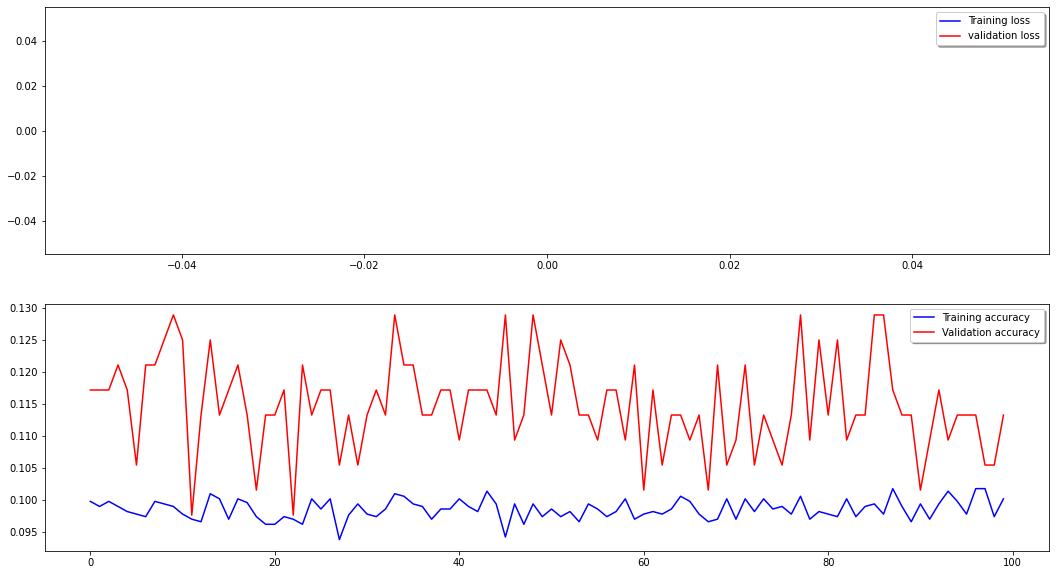

In [31]:
# Plot the loss and accuracy curves for training and validation 
fig, ax = plt.subplots(2,1, figsize=(18, 10))
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

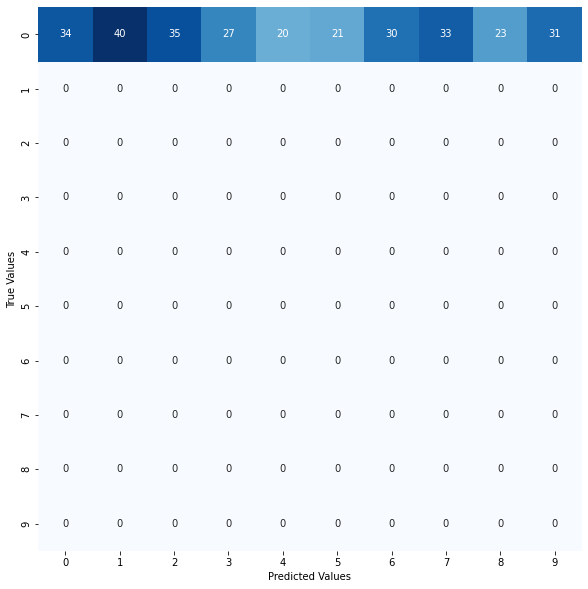

In [32]:
fig = plt.figure(figsize=(10, 10)) # Set Figure

y_pred = model.predict(X_test) # Predict class probabilities as 2 => [0.1, 0, 0.9, 0, 0, 0, 0, 0, 0, 0]

Y_pred = np.argmax(y_pred, 1) # Decode Predicted labels
Y_test = np.argmax(y_test, 1) # Decode labels

mat = confusion_matrix(Y_test, Y_pred) # Confusion matrix

# Plot Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt='.0f')
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

# Prediction

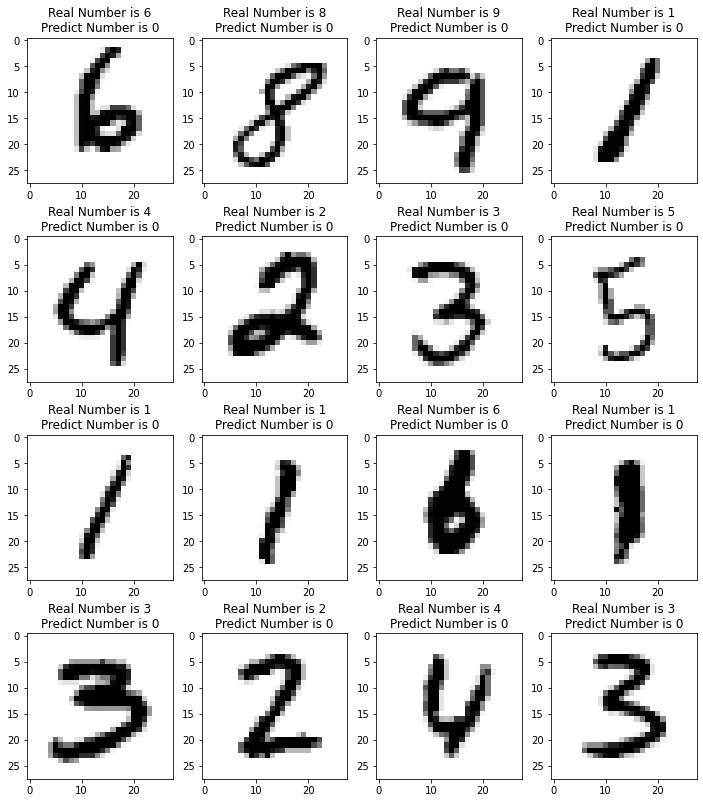

In [33]:
y_pred = model.predict(X_test)
X_test__ = X_test.reshape(X_test.shape[0], 28, 28)

fig, axis = plt.subplots(4, 4, figsize=(12, 14))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_test__[i], cmap='binary')
    ax.set(title = f"Real Number is {y_test[i].argmax()}\nPredict Number is {y_pred[i].argmax()}");